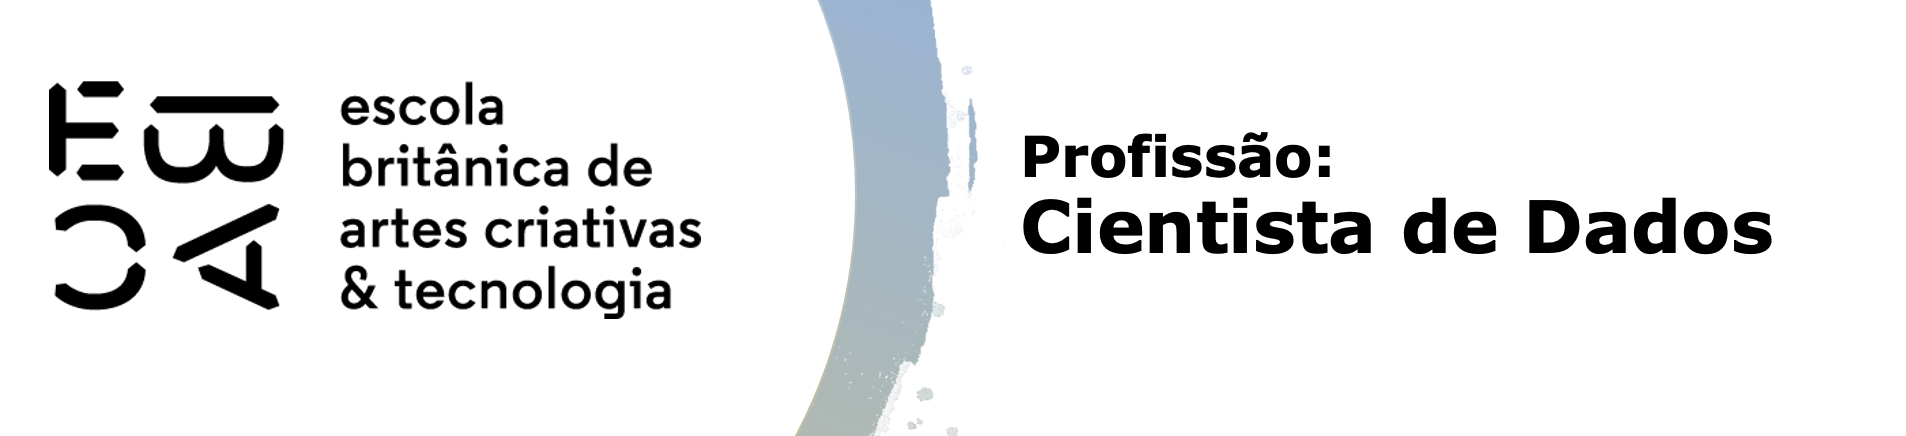

# Árvores II - Tarefa 3

### 1. Carregar as bases

Vamos utilizar nesta tarefa as bases de reconhecimento de atividade humana através do celular. Carregue novamente as bases salvas na tarefa I.

In [113]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import confusion_matrix

import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/marceloandradeam/traintest/X_test_tratado.csv
/kaggle/input/datasets/marceloandradeam/traintest/y_test.csv
/kaggle/input/datasets/marceloandradeam/traintest/y_train.csv
/kaggle/input/datasets/marceloandradeam/traintest/X_train_tratado.csv


In [114]:
ca = "/kaggle/input/datasets/marceloandradeam/traintest/"

In [115]:
X_train = pd.read_csv(
    ca + "X_train_tratado.csv",
    index_col=[0,1]
)

In [116]:
y_train = pd.read_csv(
    ca + "/y_train.csv",
    header=None
).squeeze()

In [117]:
X_test = pd.read_csv(
    ca + "/X_test_tratado.csv",
    index_col=[0,1]
)

In [118]:
y_test = pd.read_csv(
    ca + "/y_test.csv",
    header=None
).squeeze()

In [119]:
y_train = y_train.iloc[1:]
y_test = y_test.iloc[1:]

In [120]:
print(X_train.shape)
print(X_test.shape)

print(y_train.shape)
print(y_test.shape)

(7352, 561)
(2947, 561)
(7352,)
(2947,)


### 2. Calcule os ```ccp_alphas```. 

Vamos seguir uma lógica bem em linha com o que já estamso acostumados, com as seguintes orientações:

- Utilizar treinamento e teste conforme já vieram definidos originalmente
- Por pragmatismo, utilizar ```min_samples_leaf=20```
- Utilize as mesmas "3 melhores variáveis" identificadas no exercício anterior.

In [121]:
X_train2, X_val, y_train2, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.25,
    random_state=42
)

In [122]:
clf = DecisionTreeClassifier(
    max_depth=4,
    random_state=42
)

clf.fit(X_train2, y_train2)

DecisionTreeClassifier(max_depth=4, random_state=42)

In [123]:
importancias = pd.Series(
    clf.feature_importances_,
    index=X_train2.columns
)

In [124]:
melhores_variaveis = importancias.sort_values(ascending=False).head(3).index.tolist()

print(melhores_variaveis)

['tGravityAcc-min()-X', 'fBodyAccJerk-bandsEnergy()-1,16', 'tGravityAcc-mean()-Y']


In [125]:
%%time
X_train3 = X_train[melhores_variaveis]
X_test3 = X_test[melhores_variaveis]

arvore = DecisionTreeClassifier(
    min_samples_leaf=20,
    random_state=42
)

path = arvore.cost_complexity_pruning_path(X_train3, y_train)

ccp_alphas = path.ccp_alphas

ccp_alphas = np.unique(ccp_alphas[ccp_alphas > 0])

CPU times: user 35.5 ms, sys: 15 µs, total: 35.5 ms
Wall time: 34.7 ms


In [126]:
ccp_alphas = ccp_alphas[::5]

### 3. *Grid Search*

Vou deixar especificações iniciais mínimas, que visam limitar o tempo de máquina, pois um procedimento desses pode demorar muito tempo dependendo da especificação. Mas conforme você for ficando confortável com o tempo consumido pelo procedimento, pode fazer um algoritmo mais exaustivo, por exemplo, avaliando mais valores de ```ccp_alpha```.

- Meça o tempo
- Utilize a base de treinamento
- Utilize um *cross validation* do tipo *k-fold*, especifique k=10
- Você pode ler 1 a cada ```k``` valores para uma melhor varredura utilizando, por exemplo, ```ccp_alpha[::10]```
- Não se esqueça de limitar o número de variáveis

In [127]:
ccp_alphas_grid = ccp_alphas[::10]

In [128]:
from sklearn.model_selection import cross_val_score

In [129]:
%%time

resultados = []

for alpha in ccp_alphas_grid:

    clf = DecisionTreeClassifier(
        min_samples_leaf=20,
        ccp_alpha=alpha,
        random_state=42
    )

    # validação cruzada k-fold (k=10)
    scores = cross_val_score(
        clf,
        X_train3,
        y_train,
        cv=10
    )

    resultados.append(scores.mean())

CPU times: user 892 ms, sys: 1.88 ms, total: 894 ms
Wall time: 893 ms


In [130]:
melhor_indice = np.argmax(resultados)

melhor_alpha = ccp_alphas_grid[melhor_indice]
melhor_score = resultados[melhor_indice]

print("Melhor alpha:", melhor_alpha)
print("Melhor score médio (CV):", melhor_score)

Melhor alpha: 0.007225454960668447
Melhor score médio (CV): 0.8038638716356108


In [131]:
melhor_modelo = DecisionTreeClassifier(
    min_samples_leaf=20,
    ccp_alpha=melhor_alpha,
    random_state=42
)

melhor_modelo.fit(X_train3, y_train)

DecisionTreeClassifier(ccp_alpha=np.float64(0.007225454960668447),
                       min_samples_leaf=20, random_state=42)

In [132]:
acuracia_teste = melhor_modelo.score(X_test3, y_test)

print("Acurácia no teste:", acuracia_teste)

Acurácia no teste: 0.7227689175432643


### 4. Avaliando a árvore

- Obtenha a árvore na melhor configuração treinada em toda a base de treino
- Calcule a acurácia dessa árvore na base de testes
- Visualize a matriz de confusão

In [133]:
arvore_final = DecisionTreeClassifier(
    min_samples_leaf=20,
    ccp_alpha=melhor_alpha,
    random_state=42
)

arvore_final.fit(X_train3, y_train)

DecisionTreeClassifier(ccp_alpha=np.float64(0.007225454960668447),
                       min_samples_leaf=20, random_state=42)

In [134]:
acuracia_teste = arvore_final.score(X_test3, y_test)

print("Acurácia no teste:", acuracia_teste)

Acurácia no teste: 0.7227689175432643


In [135]:
y_pred = arvore_final.predict(X_test3)

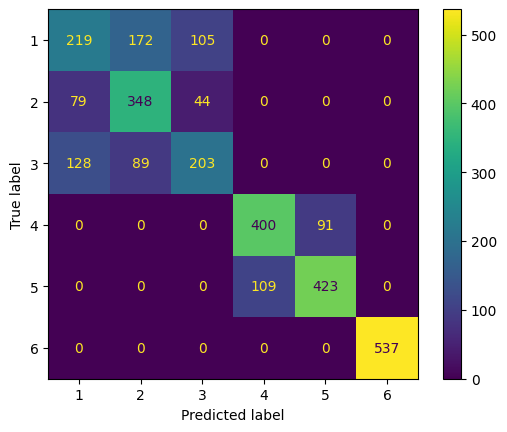

In [136]:
ConfusionMatrixDisplay.from_estimator(
    arvore_final,
    X_test3,
    y_test
)

plt.show()

### 5. Melhorando a árvore

A melhor forma de se melhorar um algoritmo é colocando nele novas variáveis que agreguem valor. Podemos usar a força-bruta e ir colocando variáveis aleatoriamente - ou colocar todas e deixar rodando por um bom tempo - ou utilizar uma lógica eficiente e fazer uma seleção de variáveis.

- Observe que há classes mais fáceis e mais difíceis de se identificar
- Crie uma variável binária para uma das classes de maior erro
- Fala uma árvore de classificação bem simples para esta variável:
    - utilize ```mean_samples_leaf=20```
    - utilize ```max_depth=4```
    - coloque todas as variáveis
- Observe a importância das variáveis, e selecione as 3 com maior importância
- Rode novamente o algoritmo acima com as 3 novas variáveis e avalie a acurácia

In [137]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[219 172 105   0   0   0]
 [ 79 348  44   0   0   0]
 [128  89 203   0   0   0]
 [  0   0   0 400  91   0]
 [  0   0   0 109 423   0]
 [  0   0   0   0   0 537]]


In [138]:
classe_alvo = 3

y_train_bin = (y_train == classe_alvo).astype(int)
y_test_bin = (y_test == classe_alvo).astype(int)

In [139]:
arv_bin = DecisionTreeClassifier(
    min_samples_leaf=20,
    max_depth=4,
    random_state=42
)

arv_bin.fit(X_train, y_train_bin)

DecisionTreeClassifier(max_depth=4, min_samples_leaf=20, random_state=42)

In [140]:
importancias = pd.Series(
    arv_bin.feature_importances_,
    index=X_train.columns
)

importancias = importancias.sort_values(ascending=False)

print(importancias.head(10))

tBodyAcc-max()-X                      0.775057
tBodyGyro-correlation()-Y,Z           0.051200
fBodyAccMag-mad()                     0.036257
tGravityAcc-arCoeff()-Z,1             0.033240
tBodyAccJerk-entropy()-X              0.023457
tBodyGyroJerk-iqr()-X                 0.023390
tBodyAccMag-mad()                     0.019762
tGravityAcc-energy()-Y                0.011872
fBodyAccJerk-bandsEnergy()-17,32.2    0.009158
tGravityAccMag-mad()                  0.006331
dtype: float64


In [141]:
novas_variaveis = importancias.head(3).index.tolist()

print(novas_variaveis)

['tBodyAcc-max()-X', 'tBodyGyro-correlation()-Y,Z', 'fBodyAccMag-mad()']


In [142]:
X_train_new = X_train[novas_variaveis]
X_test_new = X_test[novas_variaveis]

In [143]:
arvore_final = DecisionTreeClassifier(
    min_samples_leaf=20,
    ccp_alpha=melhor_alpha,
    random_state=42
)

arvore_final.fit(X_train_new, y_train)

acuracia_nova = arvore_final.score(X_test_new, y_test)

print("Nova acurácia:", acuracia_nova)

Nova acurácia: 0.5880556498133696


A matriz de confusão indica que o modelo apresenta maior dificuldade em diferenciar as classes 1, 2 e 3, que são frequentemente confundidas entre si. Por outro lado, a classe 6 apresenta excelente desempenho, sendo quase perfeitamente classificada.
O modelo otimizado com validação cruzada apresentou acurácia de aproximadamente 72% na base de teste, demonstrando boa capacidade de generalização.
A tentativa de melhoria por meio de seleção de novas variáveis focadas em uma classe específica resultou em queda de desempenho, indicando que essa abordagem não foi eficaz para o problema multiclasse.